# Pixel-to-Metre Scale Demo

Runs the trained YOLOv8 detector on a single video frame to:
1. Detect lane rope **markers** (class 0) and the **swimmer** (class 1)
2. Compute the **pixel-to-metre scale** from the known physical distance between markers
3. Project the swimmer centroid onto the lane-rope line → lateral offset in metres
4. Visualise everything on the frame


In [1]:
import os
import glob
import contextlib

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [2]:
# ── Configuration — edit these values ─────────────────────────────────────────

# Path to the trained weights produced by marker_annotation.ipynb Phase 2
YOLO_MODEL_PATH = "runs/detect/runs/detect/marker_detector/weights/best.pt"

# Folder containing the extracted JPEG frames for the video
FRAMES_DIR = "frames/under/Bottom_Breaststroke_P034_1/"

# Frame index to run the demo on
DEMO_FRAME_IDX =1200

# Real-world distance between the two lane rope markers (metres)
# Measure this physically or from pool blueprints
MARKER_REAL_DIST_M = 2.5

# Real-world height of a single lane rope marker (metres)
MARKER_HEIGHT_M = 0.6

# YOLO confidence threshold
YOLO_CONF = 0.3

Loaded frame 1200: frames/under/Bottom_Breaststroke_P034_1/frame_01200.jpg
  Resolution: 3840 x 2160 px


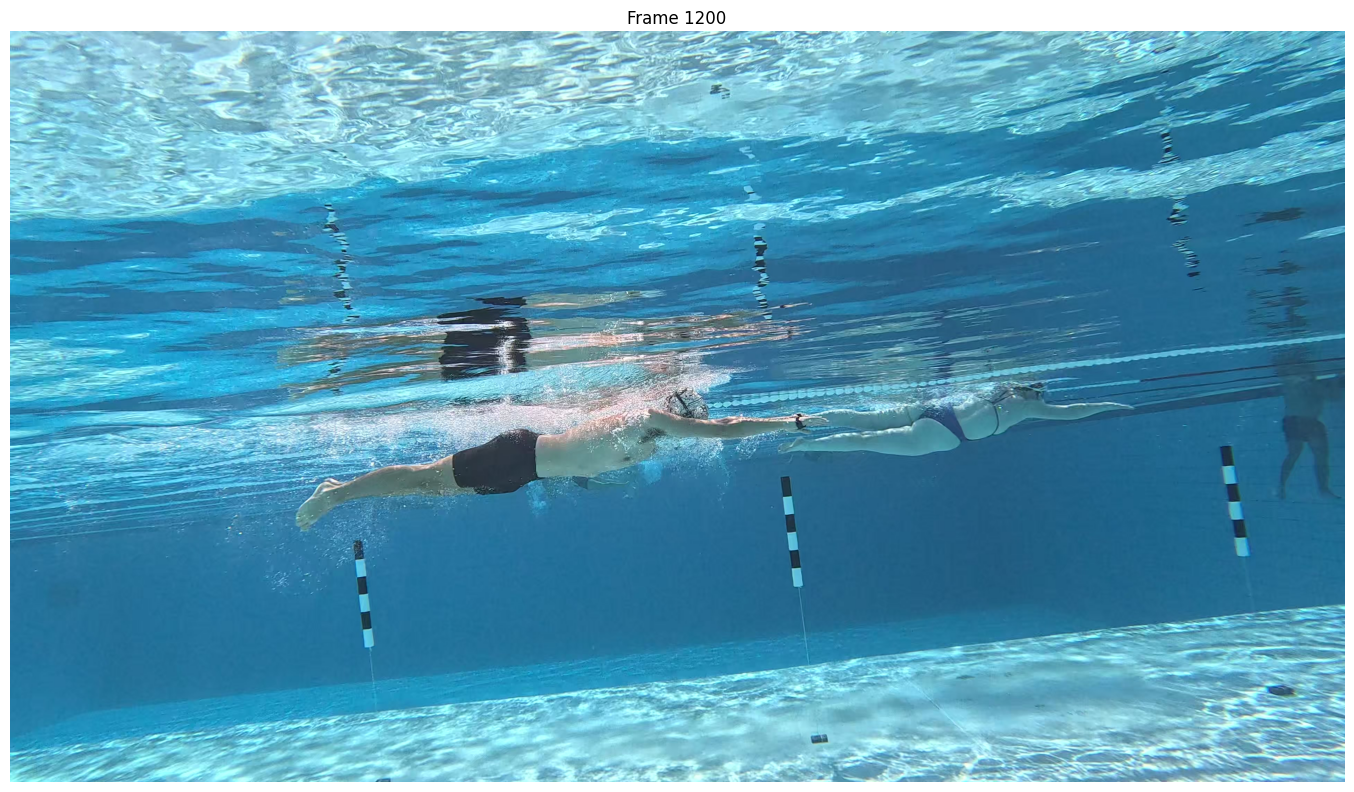

In [3]:
# ── Load frame ────────────────────────────────────────────────────────────────
frame_paths = sorted(
    glob.glob(os.path.join(FRAMES_DIR, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIR, "*.jpeg")),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.splitext(os.path.basename(p))[0])))
)
assert frame_paths, f"No JPEG frames found in {FRAMES_DIR}"
assert DEMO_FRAME_IDX < len(frame_paths), (
    f"DEMO_FRAME_IDX={DEMO_FRAME_IDX} is out of range (only {len(frame_paths)} frames)"
)

frame_path = frame_paths[DEMO_FRAME_IDX]
frame_bgr  = cv2.imread(frame_path)
assert frame_bgr is not None, f"Could not load frame: {frame_path}"
frame_rgb  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
img_h, img_w = frame_bgr.shape[:2]

print(f"Loaded frame {DEMO_FRAME_IDX}: {frame_path}")
print(f"  Resolution: {img_w} x {img_h} px")
plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
plt.title(f"Frame {DEMO_FRAME_IDX}")
plt.axis('off')
plt.tight_layout()
plt.show()

  Marker 1 detected at (1016.9, 1620.9)
  Marker 2 detected at (2248.9, 1442.1)

Total: 2 marker(s), NO swimmer


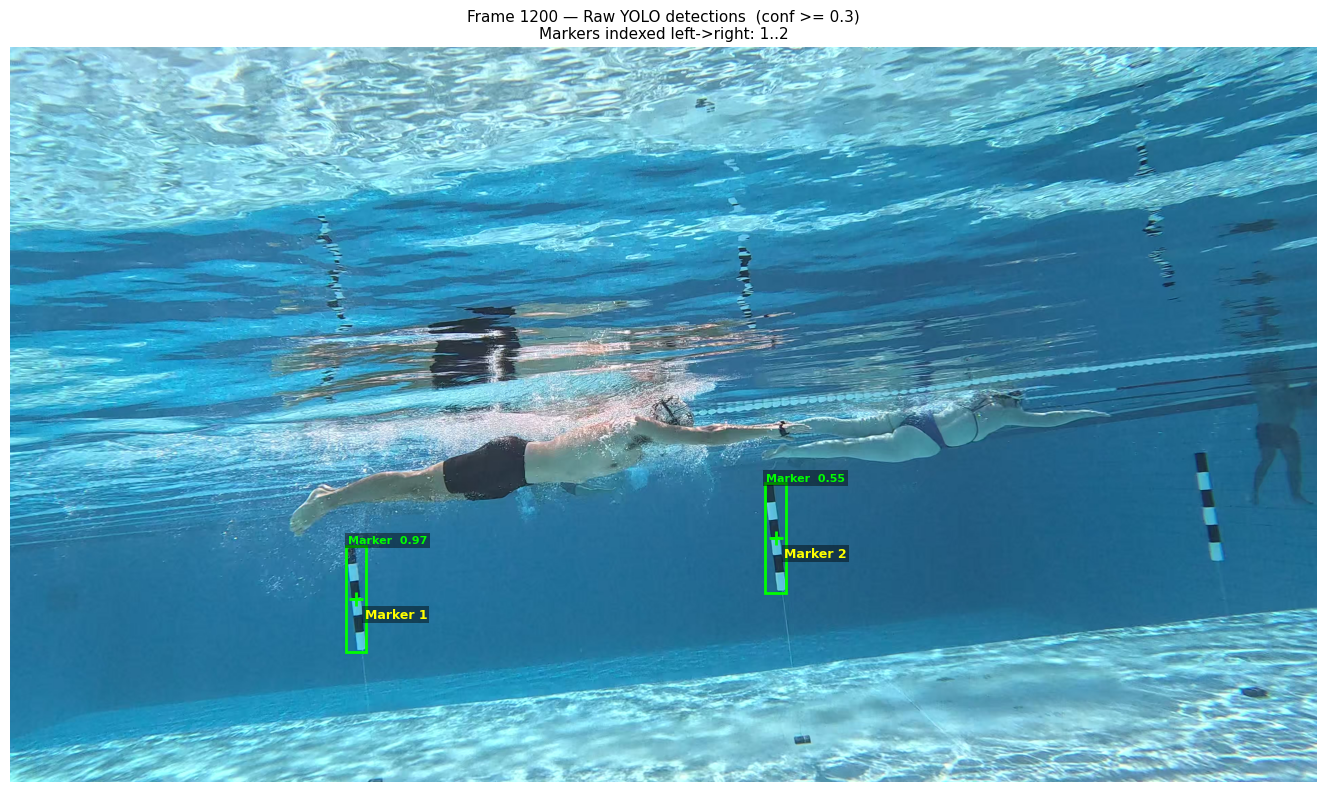

In [4]:
# ── Run YOLO detector ─────────────────────────────────────────────────────────
with contextlib.ExitStack() as stack:
    if torch.cuda.is_available():
        stack.enter_context(torch.amp.autocast("cuda", enabled=False))
    det_model = YOLO(YOLO_MODEL_PATH)
    results   = det_model(frame_bgr, conf=YOLO_CONF, verbose=False)[0]

marker_centroids = []
swimmer_centroid = None
swimmer_hbox     = None  # (x1, y1, x2, y2) for the chosen swimmer
_best_swimmer_conf = -1.0
_box_records     = []  # store for visualisation

for box in results.boxes:
    cls            = int(box.cls)
    conf           = float(box.conf)
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    cx, cy         = (x1 + x2) / 2, (y1 + y2) / 2
    _box_records.append((cls, conf, x1, y1, x2, y2, cx, cy))
    if cls == 0:
        marker_centroids.append((cx, cy))
    elif cls == 1 and conf > _best_swimmer_conf:
        _best_swimmer_conf = conf
        swimmer_centroid = (cx, cy)
        swimmer_hbox = (x1, y1, x2, y2)

# keep best 2 markers
marker_centroids = sorted(marker_centroids, key=lambda p: (p[0], p[1]))[:2]

# Stable marker indexing: left-to-right across the frame.
marker_points_sorted = sorted(marker_centroids, key=lambda p: (p[0], p[1]))

for i, (mx, my) in enumerate(marker_points_sorted, start=1):
    print(f"  Marker {i} detected at ({mx:.1f}, {my:.1f})")
if swimmer_centroid is not None and swimmer_hbox is not None:
    sx1, sy1, sx2, sy2 = swimmer_hbox
    print(f"  Swimmer detected at ({swimmer_centroid[0]:.1f}, {swimmer_centroid[1]:.1f})  conf={_best_swimmer_conf:.2f}")
    print(f"  Swimmer hbox: x=({sx1:.1f}, {sx2:.1f}) y=({sy1:.1f}, {sy2:.1f})")
print(f"\nTotal: {len(marker_points_sorted)} marker(s), {'1 swimmer' if swimmer_centroid else 'NO swimmer'}")

# ── Visualise raw detections ──────────────────────────────────────────────────
_CLASS_COLORS = {0: 'lime', 1: 'deepskyblue'}
_CLASS_NAMES  = {0: 'Marker', 1: 'Swimmer'}

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb)

for cls, conf, x1, y1, x2, y2, cx, cy in _box_records:
    color = _CLASS_COLORS.get(cls, 'white')
    label = f"{_CLASS_NAMES.get(cls, str(cls))}  {conf:.2f}"
    rect  = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                           linewidth=2, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(x1 + 4, y1 - 6, label, color=color, fontsize=8, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.45, pad=2, edgecolor='none'))
    ax.plot(cx, cy, '+', color=color, markersize=10, markeredgewidth=2)

for i, (mx, my) in enumerate(marker_points_sorted, start=1):
    ax.annotate(f"Marker {i}", (mx, my), textcoords='offset points',
                xytext=(6, -14), color='yellow', fontsize=9, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, pad=1.5, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Raw YOLO detections  (conf >= {YOLO_CONF})\n"
    f"Markers indexed left->right: 1..{len(marker_points_sorted)}",
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.show()


In [5]:
# ── Demo: choose markers nearest left/right of swimmer hbox ───────────────────
assert swimmer_centroid is not None and swimmer_hbox is not None, (
    "No swimmer detected, so left/right marker selection cannot run."
)
assert len(marker_points_sorted) >= 2, (
    f"Need at least 2 marker detections (got {len(marker_points_sorted)})."
)

sx1, sy1, sx2, sy2 = swimmer_hbox

# Prefer markers strictly outside the swimmer bounding box in x.
left_candidates  = [(i, p) for i, p in enumerate(marker_points_sorted, start=1) if p[0] < sx1]
right_candidates = [(i, p) for i, p in enumerate(marker_points_sorted, start=1) if p[0] > sx2]

selection_mode = "hbox-edges"
if left_candidates and right_candidates:
    left_idx,  left_pt  = max(left_candidates, key=lambda item: item[1][0])
    right_idx, right_pt = min(right_candidates, key=lambda item: item[1][0])
else:
    # Fallback: split by swimmer centroid x if one side of hbox has no marker.
    s_cx = swimmer_centroid[0]
    left_candidates  = [(i, p) for i, p in enumerate(marker_points_sorted, start=1) if p[0] < s_cx]
    right_candidates = [(i, p) for i, p in enumerate(marker_points_sorted, start=1) if p[0] > s_cx]
    selection_mode = "centroid-fallback"
    if left_candidates and right_candidates:
        left_idx,  left_pt  = max(left_candidates, key=lambda item: item[1][0])
        right_idx, right_pt = min(right_candidates, key=lambda item: item[1][0])
    else:
        # Last fallback: use the first two sorted markers.
        left_idx, left_pt = 1, marker_points_sorted[0]
        right_idx, right_pt = 2, marker_points_sorted[1]
        selection_mode = "first-two-fallback"

A = np.array(left_pt)
B = np.array(right_pt)
selected_marker_indices = (left_idx, right_idx)

print(f"Selection mode: {selection_mode}")
print(f"Left marker : Marker {left_idx} at ({A[0]:.1f}, {A[1]:.1f})")
print(f"Right marker: Marker {right_idx} at ({B[0]:.1f}, {B[1]:.1f})")
print(f"Swimmer hbox x-range: [{sx1:.1f}, {sx2:.1f}]")

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb)

# Draw all indexed markers first.
for i, (mx, my) in enumerate(marker_points_sorted, start=1):
    ax.plot(mx, my, 'o', color='lime', markersize=7, zorder=4)
    ax.annotate(f"M{i}", (mx, my), textcoords='offset points',
                xytext=(5, -12), color='lime', fontsize=8, fontweight='bold')

# Highlight selected left/right markers.
ax.plot(A[0], A[1], 'o', color='orange', markersize=11, zorder=6, label=f"Left marker (M{left_idx})")
ax.plot(B[0], B[1], 'o', color='deepskyblue', markersize=11, zorder=6, label=f"Right marker (M{right_idx})")

# Swimmer centroid
ax.plot(*swimmer_centroid, 'o', color='yellow', markersize=9, zorder=6, label='Swimmer centroid')


# Connect selected markers across the swimmer.
ax.plot([A[0], B[0]], [A[1], B[1]], color='white', linewidth=1.5, linestyle='--', zorder=5)

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Marker selection demo ({selection_mode})\n"
    f"Using Marker {left_idx} (left of swimmer) and Marker {right_idx} (right of swimmer)",
    fontsize=11
)
ax.legend(loc='upper right', fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()


AssertionError: No swimmer detected, so left/right marker selection cannot run.

In [6]:
# ── Geometry & pixel-to-metre computation ─────────────────────────────────────
assert swimmer_centroid is not None, (
    "No swimmer detected. Try lowering YOLO_CONF."
)

S = np.array(swimmer_centroid)
left_idx, right_idx = selected_marker_indices

AB        = B - A
AB_len_px = np.linalg.norm(AB)
AB_unit   = AB / AB_len_px

# Scale
px_per_m  = AB_len_px / MARKER_REAL_DIST_M
cm_per_px = 100 / px_per_m

print(f"Using Marker {left_idx} and Marker {right_idx} for calibration")
print(f"Marker separation : {AB_len_px:.1f} px  ({MARKER_REAL_DIST_M} m)")
print(f"Scale             : {px_per_m:.2f} px / m  |  {cm_per_px:.4f} cm / px")

# Project swimmer onto the lane-rope line: P = A + t*(B-A)
t         = np.dot(S - A, AB_unit) / AB_len_px
P         = A + t * AB

# Along-rope distances from each marker to the projected swimmer position
dist_A_px = t * AB_len_px
dist_B_px = (1.0 - t) * AB_len_px
dist_A_m  = t * MARKER_REAL_DIST_M
dist_B_m  = (1.0 - t) * MARKER_REAL_DIST_M

print(f"\nSwimmer centroid      : ({S[0]:.1f}, {S[1]:.1f}) px")
print(f"Projected point P     : ({P[0]:.1f}, {P[1]:.1f}) px")
print(f"Distance Marker{left_idx} -> P  : {dist_A_px:.1f} px  =  {dist_A_m:.4f} m  ({dist_A_m*100:.2f} cm)")
print(f"Distance Marker{right_idx} -> P : {dist_B_px:.1f} px  =  {dist_B_m:.4f} m  ({dist_B_m*100:.2f} cm)")
print(f"Along-rope param t    : {t:.4f}  (0 = Marker {left_idx}, 1 = Marker {right_idx})")

# ── Visualise scale bar ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb)

# A->P segment (left-marker side)
ax.plot([A[0], P[0]], [A[1], P[1]], color='orange', linewidth=2.5, zorder=4)
# P->B segment (right-marker side)
ax.plot([P[0], B[0]], [P[1], B[1]], color='deepskyblue', linewidth=2.5, zorder=4)

ax.plot(*A, 'o', color='orange', markersize=9, zorder=5)
ax.plot(*B, 'o', color='deepskyblue', markersize=9, zorder=5)
ax.plot(*P, 's', color='yellow', markersize=8, zorder=6, label='Projected swimmer pos')

ax.annotate(f"Marker {left_idx}", A, textcoords='offset points',
            xytext=(6, -14), color='orange', fontsize=9, fontweight='bold')
ax.annotate(f"Marker {right_idx}", B, textcoords='offset points',
            xytext=(6, -14), color='deepskyblue', fontsize=9, fontweight='bold')

mid_AP = (A + P) / 2
mid_PB = (P + B) / 2
ax.text(mid_AP[0], mid_AP[1] - 16, f"{dist_A_m:.2f} m",
        color='orange', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))
ax.text(mid_PB[0], mid_PB[1] - 16, f"{dist_B_m:.2f} m",
        color='deepskyblue', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

bar_margin  = 40
bar_y       = img_h - bar_margin
bar_x_start = bar_margin
bar_x_end   = bar_x_start + px_per_m
ax.annotate('', xy=(bar_x_end, bar_y), xytext=(bar_x_start, bar_y),
            arrowprops=dict(arrowstyle='<->', color='yellow', lw=2))
ax.text((bar_x_start + bar_x_end) / 2, bar_y - 10, "1 m",
        color='yellow', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Along-rope distances\n"
    f"Marker{left_idx}->P: {dist_A_m:.2f} m  |  Marker{right_idx}->P: {dist_B_m:.2f} m",
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.show()


AssertionError: No swimmer detected. Try lowering YOLO_CONF.

In [ ]:
# # ── Heuristic correction: likely missed intermediate marker ───────────────────
# # If one side of P is >2x the other in pixels, assume a closer marker may have
# # been missed and re-compute scale/distances with +2.5 m marker spacing.

# _EXTRA_MARKER_DIST_M = 2.5
# _short_px = min(abs(dist_A_px), abs(dist_B_px))
# _long_px  = max(abs(dist_A_px), abs(dist_B_px))
# _imbalance_ratio = (_long_px / _short_px) if _short_px > 1e-9 else np.inf

# _missing_marker_correction_applied = _imbalance_ratio > 2.0
# if _missing_marker_correction_applied:
#     effective_marker_dist_m = MARKER_REAL_DIST_M + _EXTRA_MARKER_DIST_M
#     px_per_m  = AB_len_px / effective_marker_dist_m
#     cm_per_px = 100 / px_per_m

#     dist_A_m = dist_A_px / px_per_m
#     dist_B_m = dist_B_px / px_per_m

#     print("\n[Heuristic correction triggered]")
#     print(f"Pixel imbalance ratio (long/short): {_imbalance_ratio:.2f} (> 2.0)")
#     print(f"Recomputing with marker spacing: {MARKER_REAL_DIST_M:.2f} + {_EXTRA_MARKER_DIST_M:.2f} = {effective_marker_dist_m:.2f} m")
#     print(f"Updated scale               : {px_per_m:.2f} px / m  |  {cm_per_px:.4f} cm / px")
#     print(f"Updated Marker{left_idx}->P : {dist_A_m:.4f} m  ({dist_A_m*100:.2f} cm)")
#     print(f"Updated Marker{right_idx}->P: {dist_B_m:.4f} m  ({dist_B_m*100:.2f} cm)")
# else:
#     effective_marker_dist_m = MARKER_REAL_DIST_M
#     print("\n[Heuristic correction not needed]")
#     print(f"Pixel imbalance ratio (long/short): {_imbalance_ratio:.2f} (<= 2.0)")
#     print(f"Using original marker spacing: {effective_marker_dist_m:.2f} m")

In [7]:
# ── Vertical scale from marker bounding-box heights ───────────────────────────
# Each lane-rope marker is MARKER_HEIGHT_M tall in reality; the bounding-box
# height in pixels gives us an independent vertical pixels-per-metre figure.

marker_heights_px = [y2 - y1
                     for cls, conf, x1, y1, x2, y2, cx, cy in _box_records
                     if cls == 0]
assert marker_heights_px, "No marker detections — re-run the YOLO cell"

avg_h_px   = float(np.mean(marker_heights_px))
v_px_per_m = avg_h_px / MARKER_HEIGHT_M   # vertical scale
v_h_ratio  = v_px_per_m / px_per_m        # 1.0 = already isotropic

print(f"Marker pixel heights   : {[f'{h:.1f} px' for h in marker_heights_px]}")
print(f"Mean marker height     : {avg_h_px:.1f} px  =  {MARKER_HEIGHT_M} m")
print(f"Vertical   scale       : {v_px_per_m:.2f} px / m")
print(f"Horizontal scale       : {px_per_m:.2f} px / m")
print(f"V / H ratio            : {v_h_ratio:.4f}  (1.0 = isotropic, <1 = image squashed vertically)")

# ── Visualise height scale on the raw frame ───────────────────────────────────
_VIZ_MARGIN = 40

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb)

# Draw horizontal marker-to-marker line for horizontal scale reference
ax.plot([A[0], B[0]], [A[1], B[1]], 'o--', color='lime', linewidth=1.5,
        markersize=8, zorder=4)

# For each marker bounding box: outline + height arrow
for cls, conf, x1, y1, x2, y2, cx, cy in _box_records:
    if cls != 0:
        continue
    h_px = y2 - y1
    rect = plt.Rectangle((x1, y1), x2 - x1, h_px,
                          linewidth=2, edgecolor='lime', facecolor='none')
    ax.add_patch(rect)
    # Double-headed arrow inside the box
    ax.annotate('', xy=(cx + 10, y2), xytext=(cx + 10, y1),
                arrowprops=dict(arrowstyle='<->', color='yellow', lw=1.8))
    ax.text(cx + 24, (y1 + y2) / 2,
            f"{h_px:.0f} px\n= {MARKER_HEIGHT_M} m",
            color='yellow', fontsize=8, fontweight='bold', va='center',
            bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# Horizontal 1 m reference bar (bottom-left)
h_bar_y  = img_h - _VIZ_MARGIN
h_bar_x0 = _VIZ_MARGIN + 20
h_bar_x1 = h_bar_x0 + px_per_m
ax.annotate('', xy=(h_bar_x1, h_bar_y), xytext=(h_bar_x0, h_bar_y),
            arrowprops=dict(arrowstyle='<->', color='lime', lw=2))
ax.text((h_bar_x0 + h_bar_x1) / 2, h_bar_y - 12, "1 m (H)",
        color='lime', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# Vertical 1 m reference bar (left edge)
v_bar_x  = _VIZ_MARGIN
v_bar_y1 = img_h - _VIZ_MARGIN
v_bar_y0 = v_bar_y1 - v_px_per_m
ax.annotate('', xy=(v_bar_x, v_bar_y1), xytext=(v_bar_x, v_bar_y0),
            arrowprops=dict(arrowstyle='<->', color='cyan', lw=2))
ax.text(v_bar_x + 14, (v_bar_y0 + v_bar_y1) / 2, "1 m (V)",
        color='cyan', fontsize=9, fontweight='bold', va='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Vertical scale from marker heights\n"
    f"H: {px_per_m:.1f} px/m  |  V: {v_px_per_m:.1f} px/m  |  V/H ratio = {v_h_ratio:.3f}",
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'px_per_m' is not defined

In [8]:
# ── Rectified / warped image (Perspective Transform) ──────────────────────────

# 1. DEFINE YOUR 4 SOURCE POINTS FROM YOLO BOUNDING BOXES
# Filter out only the marker boxes (class 0) and sort them left-to-right by 'cx'
marker_boxes = [box for box in _box_records if box[0] == 0]
marker_boxes_sorted = sorted(marker_boxes, key=lambda b: b[6])  # b[6] is cx

# Marker 1 (Left) bounding box: cls, conf, x1, y1, x2, y2, cx, cy
m1_y1, m1_cx = marker_boxes_sorted[0][3], marker_boxes_sorted[0][6]
A_top = [m1_cx, m1_y1]

# Marker 2 (Right) bounding box: cls, conf, x1, y1, x2, y2, cx, cy
m2_y1, m2_cx = marker_boxes_sorted[1][3], marker_boxes_sorted[1][6]
B_top = [m2_cx, m2_y1]

src_pts = np.float32([A, B, B_top, A_top])


# 2. DEFINE DESTINATION POINTS (A perfect rectangle)
# Base the width on the original distance A->B, and apply your scale factor
sy = px_per_m / v_px_per_m  # vertical correction factor
rect_width = np.linalg.norm(np.array(B) - np.array(A)) * sy
rect_height = 200.0  # Fixed pixel height for the poles in the final warped image

dst_pts_no_offset = np.float32([
    [0, rect_height],           # A lands here (bottom left)
    [rect_width, rect_height],  # B lands here (bottom right)
    [rect_width, 0],            # B_top lands here (top right)
    [0, 0]                      # A_top lands here (top left)
])

# 3. CALCULATE HOMOGRAPHY MATRIX
M_no_offset = cv2.getPerspectiveTransform(src_pts, dst_pts_no_offset)

# 4. AUTO-SIZE CANVAS
# cv2.perspectiveTransform expects a specific 3D array shape: (-1, 1, 2)
corners_src = np.float32(
    [[0, 0], [img_w, 0], [img_w, img_h], [0, img_h]]).reshape(-1, 1, 2)
corners_dst = cv2.perspectiveTransform(corners_src, M_no_offset).reshape(-1, 2)

x_min, y_min = corners_dst.min(axis=0)
x_max, y_max = corners_dst.max(axis=0)
out_w_warp = int(np.ceil(x_max - x_min)) + 1
out_h_warp = int(np.ceil(y_max - y_min)) + 1

# 5. SHIFT TO POSITIVE COORDINATES
T2 = np.array([[1, 0, -x_min],
               [0, 1, -y_min],
               [0, 0,  1.0]])

M_full = T2 @ M_no_offset

# 6. WARP THE IMAGE (Using warpPerspective)
warped_bgr = cv2.warpPerspective(frame_bgr, M_full, (out_w_warp, out_h_warp),
                                 flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_CONSTANT,
                                 borderValue=(0, 0, 0))
warped_rgb = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB)

# 7. UPDATE POINT WARPING FUNCTION
# Homography requires dividing by the Z-coordinate (the 3rd element) after matrix multiplication


def _warp_pt(pt):
    pt_3d = M_full @ np.array([float(pt[0]), float(pt[1]), 1.0])
    return (pt_3d[:2] / pt_3d[2])


A_w = _warp_pt(A)
B_w = _warp_pt(B)
S_w = _warp_pt(S)
P_w = _warp_pt(P)
warped_marker_points = [_warp_pt(np.array(pt)) for pt in marker_points_sorted]

warped_px_per_m = px_per_m   # isotropic after correction

print(f"Output canvas           : {out_w_warp} × {out_h_warp} px")
print(f"Warped A → B  ΔY        : {abs(B_w[1] - A_w[1]):.4f} px  (≈ 0 ✓)")
print(f"Warped scale (isotropic): {warped_px_per_m:.2f} px / m")
print(f"  Marker1→P : {dist_A_m:.2f} m  |  P→Marker2 : {dist_B_m:.2f} m")

# ── Visualise the rectified image ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(warped_rgb)

# Lane-rope line — exactly horizontal after warp
ax.axhline(y=A_w[1], color='lime', linewidth=1.5, linestyle='--',
           label='Lane rope (horizontal)')

# Markers (indexed left-to-right in original frame)
for i, m_w in enumerate(warped_marker_points, start=1):
    ax.plot(*m_w, 'o', color='lime', markersize=10, zorder=5)
    ax.annotate(f'Marker {i}', m_w, textcoords='offset points',
                xytext=(6, -14), color='lime', fontsize=9, fontweight='bold')

# Projected point P
ax.plot(*P_w, 's', color='yellow', markersize=9,
        zorder=6, label='Projected position P')

# A_w → P_w segment (orange) with distance label
ax.plot([A_w[0], P_w[0]], [A_w[1], P_w[1]], color='orange', linewidth=2.5,
        label=f'Marker1 → P = {dist_A_m:.2f} m')
mid_AP_w = (A_w + P_w) / 2
ax.text(mid_AP_w[0], mid_AP_w[1] - 16, f"{dist_A_m:.2f} m",
        color='orange', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# P_w → B_w segment (cyan) with distance label
ax.plot([P_w[0], B_w[0]], [P_w[1], B_w[1]], color='deepskyblue', linewidth=2.5,
        label=f'P → Marker2 = {dist_B_m:.2f} m')
mid_PB_w = (P_w + B_w) / 2
ax.text(mid_PB_w[0], mid_PB_w[1] - 16, f"{dist_B_m:.2f} m",
        color='deepskyblue', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# Swimmer centroid
ax.plot(*S_w, 'o', color='deepskyblue',
        markersize=10, zorder=5, label='Swimmer')

# Isotropic 1 m scale bar
_sb_margin = 40
_sb_x0 = _sb_margin
_sb_y = out_h_warp - _sb_margin
_sb_x1 = _sb_x0 + warped_px_per_m
ax.annotate('', xy=(_sb_x1, _sb_y), xytext=(_sb_x0, _sb_y),
            arrowprops=dict(arrowstyle='<->', color='yellow', lw=2))
ax.text((_sb_x0 + _sb_x1) / 2, _sb_y - 12, "1 m",
        color='yellow', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Rectified image  "
    f"(lane rope horizontal, scale isotropic, perspective fixed)\n"
    f"{warped_px_per_m:.1f} px/m  |  "
    f"Marker1→P: {dist_A_m:.2f} m  |  P→Marker2: {dist_B_m:.2f} m",
    fontsize=10
)
ax.legend(loc='upper right', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'A' is not defined

In [9]:
# ── Geometry & pixel-to-metre computation (WARPED SPACE) ──────────────────────
assert swimmer_centroid is not None, (
    "No swimmer detected. Try lowering YOLO_CONF."
)

# Use the warped points generated by the perspective transform
S_w = np.array(S_w)
left_idx, right_idx = selected_marker_indices

AB_w = B_w - A_w
AB_len_px_w = np.linalg.norm(AB_w)
AB_unit_w = AB_w / AB_len_px_w

# Scale (Warped)
warped_px_per_m = AB_len_px_w / MARKER_REAL_DIST_M
cm_per_px_w = 100 / warped_px_per_m

print(f"Using Marker {left_idx} and Marker {right_idx} for calibration")
print(
    f"Warped Marker separation : {AB_len_px_w:.1f} px  ({MARKER_REAL_DIST_M} m)")
print(
    f"Warped Scale             : {warped_px_per_m:.2f} px / m  |  {cm_per_px_w:.4f} cm / px")

# Project swimmer onto the lane-rope line in warped space: P_w = A_w + t*(B_w - A_w)
t = np.dot(S_w - A_w, AB_unit_w) / AB_len_px_w
P_w = A_w + t * AB_w

# Along-rope distances from each marker to the projected swimmer position
dist_A_px_w = t * AB_len_px_w
dist_B_px_w = (1.0 - t) * AB_len_px_w
dist_A_m = t * MARKER_REAL_DIST_M
dist_B_m = (1.0 - t) * MARKER_REAL_DIST_M

print(f"\nWarped Swimmer centroid  : ({S_w[0]:.1f}, {S_w[1]:.1f}) px")
print(f"Warped Projected point P : ({P_w[0]:.1f}, {P_w[1]:.1f}) px")
print(
    f"Distance Marker{left_idx} -> P  : {dist_A_px_w:.1f} px  =  {dist_A_m:.4f} m  ({dist_A_m*100:.2f} cm)")
print(
    f"Distance Marker{right_idx} -> P : {dist_B_px_w:.1f} px  =  {dist_B_m:.4f} m  ({dist_B_m*100:.2f} cm)")
print(
    f"Along-rope param t       : {t:.4f}  (0 = Marker {left_idx}, 1 = Marker {right_idx})")

# ── Visualise scale bar ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
# Swap frame_rgb for warped_rgb
ax.imshow(warped_rgb)

# A_w->P_w segment (left-marker side)
ax.plot([A_w[0], P_w[0]], [A_w[1], P_w[1]],
        color='orange', linewidth=2.5, zorder=4)
# P_w->B_w segment (right-marker side)
ax.plot([P_w[0], B_w[0]], [P_w[1], B_w[1]],
        color='deepskyblue', linewidth=2.5, zorder=4)

# Plot using warped points
ax.plot(*A_w, 'o', color='orange', markersize=9, zorder=5)
ax.plot(*B_w, 'o', color='deepskyblue', markersize=9, zorder=5)
ax.plot(*P_w, 's', color='yellow', markersize=8,
        zorder=6, label='Projected swimmer pos')

ax.annotate(f"Marker {left_idx}", A_w, textcoords='offset points',
            xytext=(6, -14), color='orange', fontsize=9, fontweight='bold')
ax.annotate(f"Marker {right_idx}", B_w, textcoords='offset points',
            xytext=(6, -14), color='deepskyblue', fontsize=9, fontweight='bold')

# Text labels for distance
mid_AP = (A_w + P_w) / 2
mid_PB = (P_w + B_w) / 2
ax.text(mid_AP[0], mid_AP[1] - 16, f"{dist_A_m:.2f} m",
        color='orange', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))
ax.text(mid_PB[0], mid_PB[1] - 16, f"{dist_B_m:.2f} m",
        color='deepskyblue', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# Scale bar
bar_margin = 40
# Swap img_h for out_h_warp to keep the scale bar at the bottom of the new canvas
bar_y = out_h_warp - bar_margin
bar_x_start = bar_margin
bar_x_end = bar_x_start + warped_px_per_m
ax.annotate('', xy=(bar_x_end, bar_y), xytext=(bar_x_start, bar_y),
            arrowprops=dict(arrowstyle='<->', color='yellow', lw=2))
ax.text((bar_x_start + bar_x_end) / 2, bar_y - 10, "1 m",
        color='yellow', fontsize=10, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Along-rope distances (WARPED)\n"
    f"Marker{left_idx}->P: {dist_A_m:.2f} m  |  Marker{right_idx}->P: {dist_B_m:.2f} m",
    fontsize=11
)
ax.axis('off')
plt.tight_layout()
plt.show()

AssertionError: No swimmer detected. Try lowering YOLO_CONF.

NameError: name 'AB' is not defined

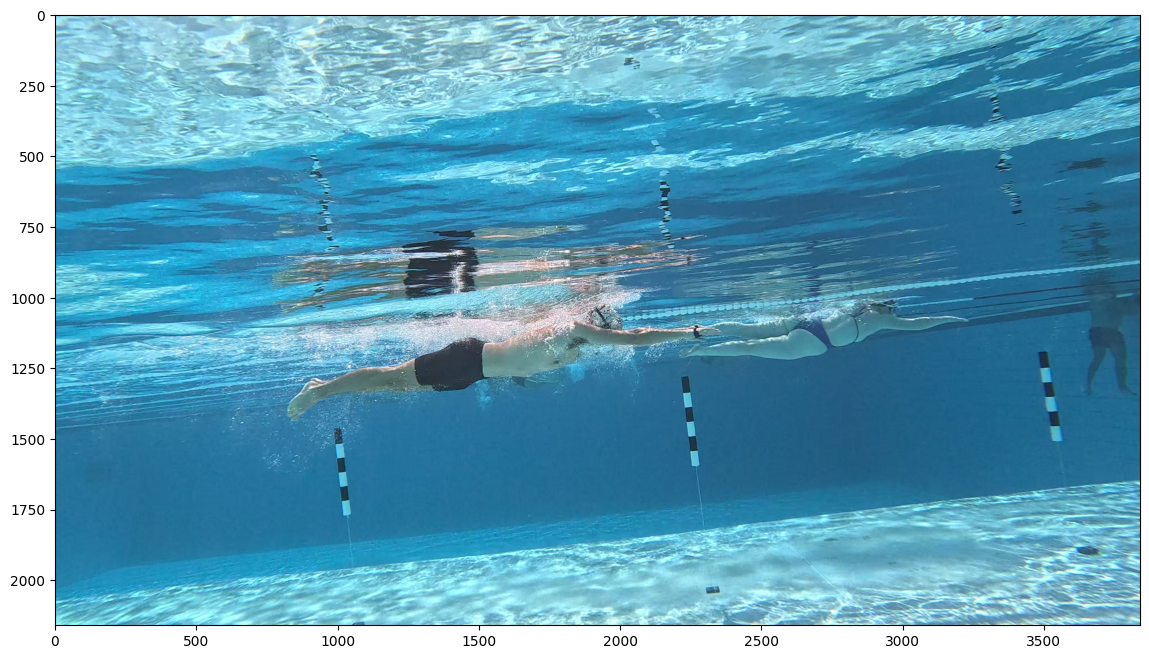

In [10]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(frame_rgb)

# Extend the lane-rope line across the whole image for visibility
if abs(AB[0]) > 1e-6:
    t_left  = (0     - A[0]) / AB[0]
    t_right = (img_w - A[0]) / AB[0]
    t_lo, t_hi = sorted([t_left, t_right])
else:
    t_lo, t_hi = -0.5, 1.5

ls = A + t_lo * AB
le = A + t_hi * AB
ax.plot([ls[0], le[0]], [ls[1], le[1]],
        color='lime', linewidth=1.5, linestyle='--', label='Lane rope line')

# Markers (indexed left-to-right)
for i, (mx, my) in enumerate(marker_points_sorted, start=1):
    ax.plot(mx, my, 'o', color='lime', markersize=10, zorder=5)
    ax.annotate(f'Marker {i}', (mx, my), textcoords='offset points',
                xytext=(6, -14), color='lime', fontsize=9, fontweight='bold')

# Swimmer
ax.plot(*S, 'o', color='deepskyblue', markersize=10, zorder=5, label='Swimmer centroid')
ax.annotate('Swimmer', S, textcoords='offset points',
            xytext=(6, -14), color='deepskyblue', fontsize=9, fontweight='bold')

# Projected point P on the rope
ax.plot(*P, 's', color='yellow', markersize=9, zorder=6, label='Projected position P')

# A → P segment (orange) with distance label
ax.plot([A[0], P[0]], [A[1], P[1]], color='orange', linewidth=2.5,
        label=f'Marker1 → P = {dist_A_m:.2f} m')
mid_AP = (A + P) / 2
ax.text(mid_AP[0], mid_AP[1] - 16, f"{dist_A_m:.2f} m",
        color='orange', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

# P → B segment (cyan) with distance label
ax.plot([P[0], B[0]], [P[1], B[1]], color='deepskyblue', linewidth=2.5,
        label=f'P → Marker2 = {dist_B_m:.2f} m')
mid_PB = (P + B) / 2
ax.text(mid_PB[0], mid_PB[1] - 16, f"{dist_B_m:.2f} m",
        color='deepskyblue', fontsize=9, fontweight='bold', ha='center',
        bbox=dict(facecolor='black', alpha=0.5, pad=2, edgecolor='none'))

ax.set_title(
    f"Frame {DEMO_FRAME_IDX} — Swimmer position along lane rope\n"
    f"Scale: {px_per_m:.1f} px/m  |  "
    f"Marker1→P: {dist_A_m:.2f} m  |  P→Marker2: {dist_B_m:.2f} m",
    fontsize=11
)
ax.legend(loc='upper right', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()
